In [1]:
#  AI MEDICINE PRICE PREDICTION SYSTEM
# ==========================================

# 1. DATA COLLECTION

import pandas as pd
import numpy as np

df = pd.read_csv("D:\ML project\Extensive_A_Z_medicines_dataset_of_India.csv")

print("Dataset Loaded Successfully")
print(df.shape)

Dataset Loaded Successfully
(256476, 24)


In [2]:
## 2. DATA CLEANING

## Remove duplicates
df = df.drop_duplicates()

## Standardize column names
df.columns = df.columns.str.lower().str.strip()

## Detect price column
price_col = [col for col in df.columns if "price" in col][0]

## Convert price to numeric
df[price_col] = pd.to_numeric(df[price_col], errors='coerce')

## Fill missing values properly
df[price_col] = df[price_col].fillna(df[price_col].median())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna("Unknown")

print("Data Cleaning Done")


Data Cleaning Done


In [3]:

# 3. FEATURE ENGINEERING

# Combine compositions (NLP feature)
df['composition'] = (
    df.get('short_composition1', '').astype(str) + " " +
    df.get('short_composition2', '').astype(str)
)


In [4]:
# Price category (target)
df['price_category'] = pd.qcut(df[price_col], q=3, labels=["Low", "Medium", "High"])


In [6]:
# 4. EDA (Exploratory Data Analysis)

import matplotlib.pyplot as plt

print("\n BASIC INFO")
print(df.info())

print("\n STATISTICS")
print(df.describe())



 BASIC INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256476 entries, 0 to 256475
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype   
---  ------                     --------------   -----   
 0   id                         256476 non-null  int64   
 1   name                       256476 non-null  object  
 2   price(₹)                   256476 non-null  float64 
 3   is_discontinued            256476 non-null  bool    
 4   manufacturer_name          256476 non-null  object  
 5   type                       256476 non-null  object  
 6   pack_size_label            256476 non-null  object  
 7   short_composition1         256476 non-null  object  
 8   short_composition2         256476 non-null  object  
 9   substitute0                256476 non-null  object  
 10  substitute1                256476 non-null  object  
 11  substitute2                256476 non-null  object  
 12  substitute3                256476 non-null  object  
 13  s

In [7]:

#  SMART INSIGHTS


print("\n Insight 1: Average Price by Medicine Type")
print(df.groupby('type')[price_col].mean().sort_values(ascending=False))

print("\n Insight 2: Top 5 Most Expensive Manufacturers")
print(df.groupby('manufacturer_name')[price_col].mean().sort_values(ascending=False).head())

print("\n Insight 3: Price Category Distribution")
print(df['price_category'].value_counts())


 Insight 1: Average Price by Medicine Type
type
allopathy    270.493273
Name: price(₹), dtype: float64

 Insight 2: Top 5 Most Expensive Manufacturers
manufacturer_name
Roche Products India Pvt Ltd         47397.537391
Astellas Pharma Inc                  39597.022222
BMS India Pvt  Ltd                   33679.436250
Biogen Idec Biotech India Pvt Ltd    29269.000000
Gennova Biopharmaceuticals Ltd       26102.116667
Name: price(₹), dtype: float64

 Insight 3: Price Category Distribution
price_category
Low       86169
Medium    86060
High      84247
Name: count, dtype: int64


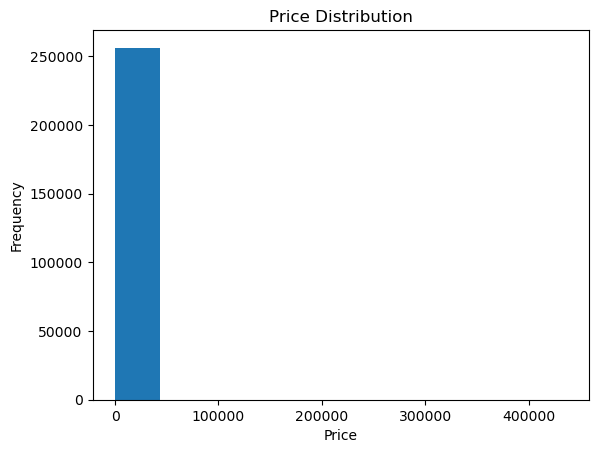

In [8]:
# Price distribution
plt.figure()
plt.hist(df[price_col])
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

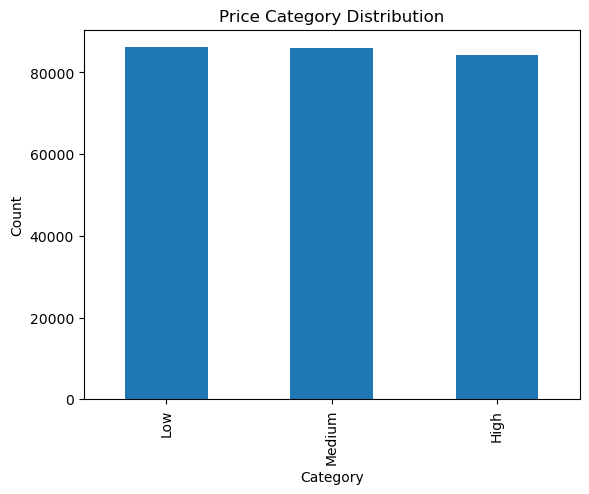

In [9]:
# Price Category Distribution
plt.figure()
df['price_category'].value_counts().plot(kind='bar')
plt.title("Price Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

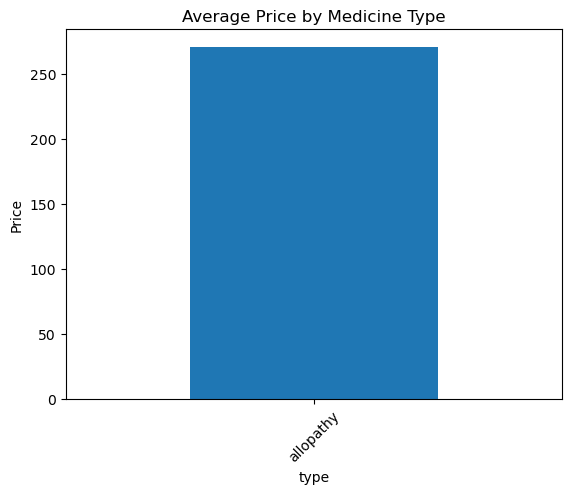

In [10]:
# Average Price by Type
plt.figure()
df.groupby('type')[price_col].mean().plot(kind='bar')
plt.title("Average Price by Medicine Type")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()


 Top Manufacturers:
manufacturer_name
Sun Pharmaceutical Industries Ltd    2999
Cipla Ltd                            2501
Intas Pharmaceuticals Ltd            2336
Torrent Pharmaceuticals Ltd          2053
Alkem Laboratories Ltd               1844
Abbott                               1810
Zydus Cadila                         1786
Lupin Ltd                            1751
Micro Labs Ltd                       1332
Mankind Pharma Ltd                   1323
Name: count, dtype: int64


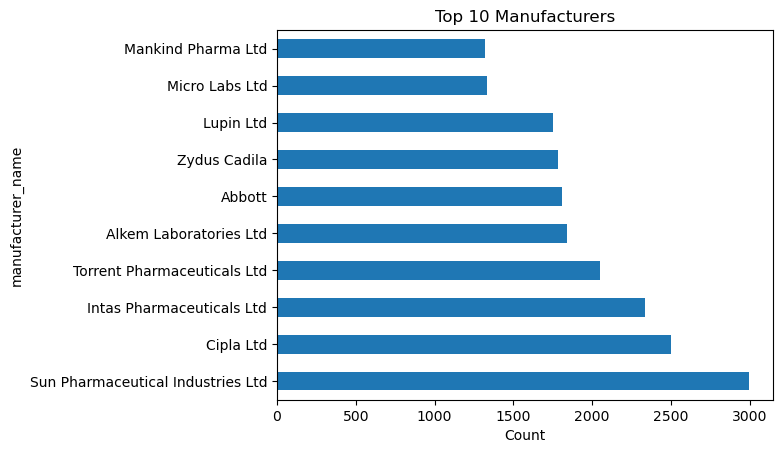

In [11]:
# Top manufacturers
print("\n Top Manufacturers:")
print(df['manufacturer_name'].value_counts().head(10))
# Top Manufacturers (Barh)
plt.figure()
df['manufacturer_name'].value_counts().head(10).plot(kind='barh')
plt.title("Top 10 Manufacturers")
plt.xlabel("Count")
plt.show()

In [12]:

# 5. PREPROCESSING PIPELINE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer

X = df[['manufacturer_name', 'type', 'composition']]
y = df['price_category']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['manufacturer_name', 'type']),
    ('text', TfidfVectorizer(max_features=30), 'composition')
])

In [13]:

# 6. TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [14]:

# 7A. RANDOM FOREST

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(
    n_estimators=20,
    max_depth=10,
    n_jobs=-1   #  USE ALL CPU CORES
))  # reduced for speed
])

rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)

print("\n Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))


 Random Forest
Accuracy: 0.48793278228321896
              precision    recall  f1-score   support

        High       0.66      0.45      0.53     16850
         Low       0.42      0.78      0.55     17234
      Medium       0.51      0.24      0.32     17212

    accuracy                           0.49     51296
   macro avg       0.53      0.49      0.47     51296
weighted avg       0.53      0.49      0.47     51296



In [15]:

# 7B. GRADIENT BOOSTING

from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', GradientBoostingClassifier())
])

gb_pipeline.fit(X_train, y_train)
gb_preds = gb_pipeline.predict(X_test)

print("\n Gradient Boosting")
print("Accuracy:", accuracy_score(y_test, gb_preds))
print(classification_report(y_test, gb_preds))


 Gradient Boosting
Accuracy: 0.570609794135995
              precision    recall  f1-score   support

        High       0.60      0.60      0.60     16850
         Low       0.57      0.62      0.60     17234
      Medium       0.54      0.48      0.51     17212

    accuracy                           0.57     51296
   macro avg       0.57      0.57      0.57     51296
weighted avg       0.57      0.57      0.57     51296



In [16]:

# 7C. LOGISTIC REGRESSION

from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)

print("\n Logistic Regression")
print("Accuracy:", accuracy_score(y_test, lr_preds))
print(classification_report(y_test, lr_preds))


 Logistic Regression
Accuracy: 0.5664769182782283
              precision    recall  f1-score   support

        High       0.60      0.67      0.63     16850
         Low       0.59      0.57      0.58     17234
      Medium       0.51      0.46      0.49     17212

    accuracy                           0.57     51296
   macro avg       0.56      0.57      0.56     51296
weighted avg       0.56      0.57      0.56     51296



In [17]:

# 8. BEST MODEL (MANUAL)

rf_acc = accuracy_score(y_test, rf_preds)
gb_acc = accuracy_score(y_test, gb_preds)
lr_acc = accuracy_score(y_test, lr_preds)

if rf_acc >= gb_acc and rf_acc >= lr_acc:
    best_model = rf_pipeline
    print(" Best Model: Random Forest")

elif gb_acc >= rf_acc and gb_acc >= lr_acc:
    best_model = gb_pipeline
    print(" Best Model: Gradient Boosting")

else:
    best_model = lr_pipeline
    print(" Best Model: Logistic Regression")

 Best Model: Gradient Boosting


In [18]:
import pickle
pickle.dump(best_model, open("best_model.pkl", "wb"))
print("Model Saved Successfully ")

Model Saved Successfully 


In [4]:
print("\n Sample Prediction Result:")

if prediction[0] == "Low":
    print(" This medicine is in LOW price range")
elif prediction[0] == "Medium":
    print(" This medicine is in MEDIUM price range")
else:
    print(" This medicine is in HIGH price range")


 Sample Prediction Result:


NameError: name 'prediction' is not defined